In [1]:
from oncapintada.phase_diagram import PhaseDiagram
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from oncapintada import __version__
print(f"oncapintada version: {__version__}")

oncapintada version: 26.3.6


In [2]:
ntemp = 301
ncomp = 1001

temperatures = np.linspace(0, 3000, ntemp)
print(f"Temperatures: from {temperatures[0]} K to {temperatures[-1]} K with {len(temperatures)} points")

x = np.linspace(0, 1, ncomp)
print(f"Compositions: from {x[0]} to {x[-1]} with {len(x)} points")

Temperatures: from 0.0 K to 3000.0 K with 301 points
Compositions: from 0.0 to 1.0 with 1001 points


In [ ]:
# X_Pt = x, X_Au = 1-x    # x is for the 2nd element
# MAuPt = 34.280          # M_{Au[Pt]}, Au substitution in Pt bulk
# MPtAu = -3.312          # M_{Pt[Au]}, Pt substitution in Au bulk

M12 = -6.971              # M_{1[2]}, 1 substitution in 2 bulk
M21 = 43.374              # M_{2[1]}, 2 substitution in 1 bulk

enthalpy = (M12 * (1-x) + M21 * x) * x * (1-x)

enthalpy = np.array(enthalpy)
eps = 1E-8
entropy = - 8.314 / 1000 * (x * np.log(x + eps) + (1-x) * np.log(1-x + eps))

# Matrix (ncomp x ntemp) for Enthalpy and Entropy
enthalpy_matrix = np.tile(enthalpy, (ntemp, 1)).T
entropy_matrix = np.tile(entropy, (ntemp, 1)).T

free_energy = enthalpy_matrix - temperatures[np.newaxis, :] * entropy_matrix
free_energy.shape

(1001, 301)

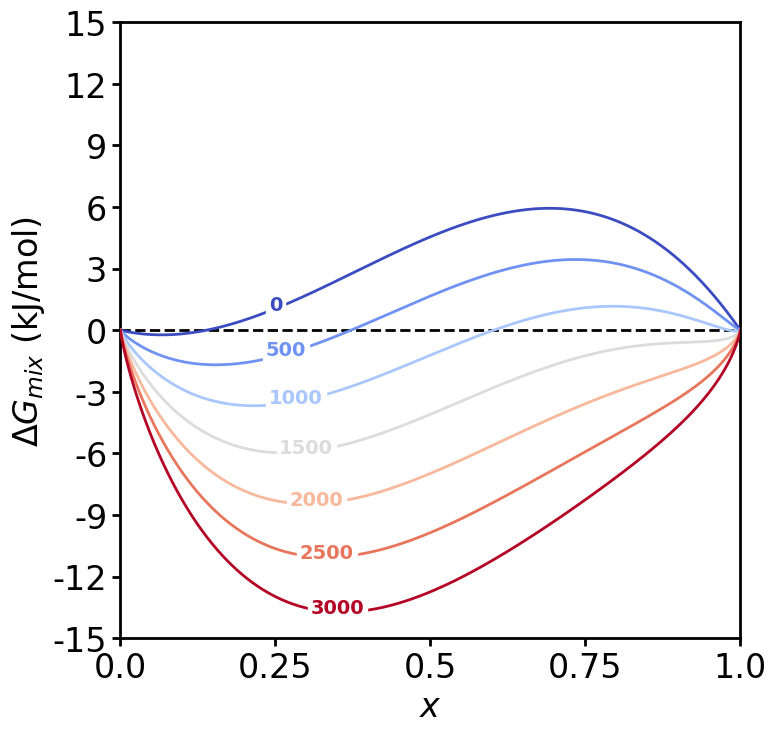

In [7]:
fig, ax = plt.subplots(figsize=(8,8))

fontsize=24
linewidth=2
ntemp = free_energy.shape[1]

colors = sns.color_palette("coolwarm", n_colors=ntemp)              # Options: "RdBu_r"

# Baseline black dased line at G=0
ax.axhline(0, color='black', linestyle='--', linewidth=linewidth, zorder=1)

for i in range(ntemp)[::50]:                                        # Plot every n temperatures for clarity
    ax.plot(x, free_energy[:, i], color=colors[i], lw=linewidth, zorder=3)
    x_pos = 0.25 + i/ntemp * 0.1                                    # Position the label along the x-axis
    y_pos = np.interp(x_pos, x, free_energy[:, i]) + 0.2            # Interpolate to find the y position at x_pos
    ax.text(x_pos, y_pos , str(int(temperatures[i])), 
            color=colors[i], 
            fontsize=14,
            fontweight='bold',
            ha='center',
            va='center',
            backgroundcolor='white',
            bbox=dict(facecolor='white', edgecolor='white', pad=2.0, alpha=1.0))

ax.set_xlabel("$x$", fontsize=fontsize)
ax.set_ylabel(r"$\Delta G_{mix}$ (kJ/mol)", fontsize=fontsize)
ax.set_xlim(0, 1)
ax.set_xticks(np.linspace(0, 1, 5))
ax.set_xticklabels(np.linspace(0, 1, 5), fontsize=fontsize)
emin, emax = -15, 16
estep = 3
ax.set_yticks(np.arange(emin, emax, estep))
ax.set_yticklabels(np.arange(emin, emax, estep), fontsize=fontsize)

# ax.legend(fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=fontsize, width=linewidth, length=6, direction='out')
for spine in ax.spines.values():
    spine.set_linewidth(linewidth)

fig.savefig('free_energy_phase_diagram.png', dpi=600, bbox_inches='tight')
plt.show()

In [84]:
# Save free_energy dataframe with pandas. No labels for now, just the data. We can add labels later if needed.
gibbs_df = pd.DataFrame(free_energy, index=x, columns=temperatures, dtype=np.float64)
gibbs_df.index.name = 'x'
gibbs_df.columns.name = 'T'



In [ ]:
# Save CSV file
# gibbs_df.to_csv('free_energy_data.csv')

# Load CSV file
# gibbs_df = pd.read_csv('free_energy_data.csv', index_col=0)

In [85]:
ntemp, ncomp = gibbs_df.values.shape
print(f"Number of temperatures (t): {ntemp}")
print(f"Number of compositions (x): {ncomp}")

phase_diagram = PhaseDiagram(gibbs_df)

Number of temperatures (t): 1001
Number of compositions (x): 301


In [86]:
binodal_curve = phase_diagram.binodal_curve(ninterp=20)
binodal_curve


,x,t
0,0.070,0.0
1,0.072,10.0
2,0.075,20.0
3,0.077,30.0
4,0.080,40.0
...,...,...
501,1.000,180.0
502,1.000,420.0
503,1.000,190.0
504,1.000,150.0


In [87]:
spinodal_curve = phase_diagram.spinodal_curve(atol=1e-8)
spinodal_curve.head()

,x,t
0,0.379488,0.0
1,0.380656,10.0
2,0.381820,20.0
3,0.382982,30.0
4,0.384142,40.0


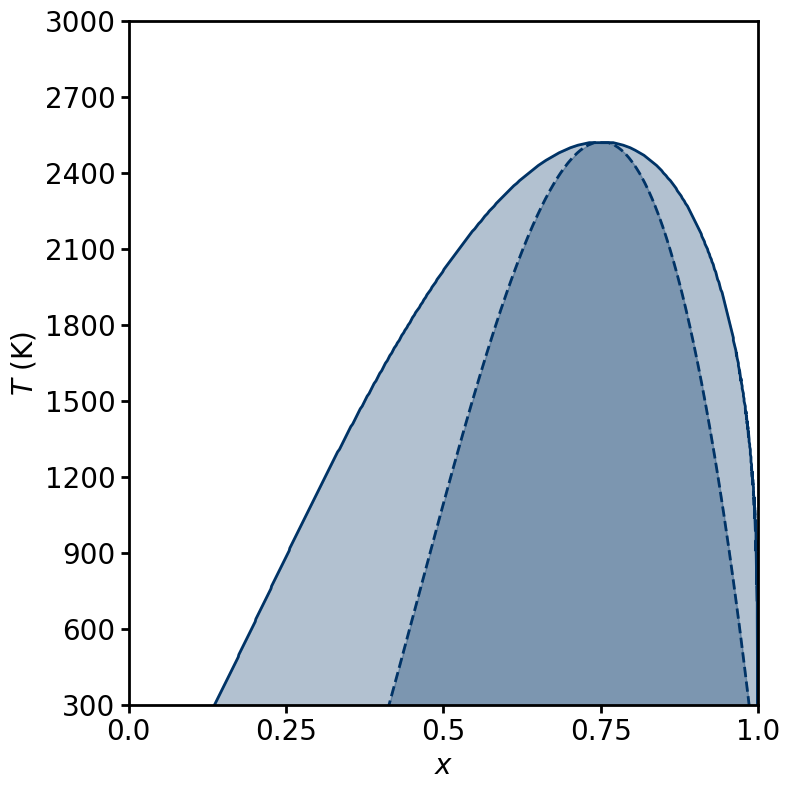

In [116]:
fig, ax = plt.subplots(figsize=(8,8))

fontsize=20
linewidth=2
# colors = sns.color_palette("RdBu_r", n_colors=ntemp)
color_binodal = "#003366"
color_spinodal = "#003366"
transparency = 0.3

ax.plot(binodal_curve['x'], binodal_curve['t'], linestyle='-', color=color_binodal, lw=linewidth, label='Binodal Curve')
ax.plot(spinodal_curve['x'], spinodal_curve['t'], linestyle='--', color=color_spinodal, lw=linewidth, label='Spinodal Curve')
ax.fill_between(binodal_curve['x'], binodal_curve['t'], color=color_binodal, alpha=transparency)
ax.fill_between(spinodal_curve['x'], spinodal_curve['t'], color=color_spinodal, alpha=transparency)

ax.set_xlabel("$x$", fontsize=fontsize)
ax.set_ylabel(r"$T$ (K)" , fontsize=fontsize)
ax.set_xlim(0, 1)
ax.set_ylim(300, 3000)
ax.set_xticks(np.linspace(0, 1, 5))
ax.set_xticklabels(np.linspace(0, 1, 5), fontsize=fontsize)
ax.set_yticks(np.arange(300, 3001, 300))

ax.tick_params(axis='both', which='major', labelsize=fontsize, width=linewidth, length=6, direction='out')
for spine in ax.spines.values():
    spine.set_linewidth(linewidth)

# plt.legend(loc="best", fontsize=fontsize)
plt.tight_layout()
fig.savefig('phase_diagram.png', dpi=600, bbox_inches='tight')
plt.show()